In [67]:
using LinearAlgebra
using LinearOperators
using SparseArrays
include("main.jl")

get_grid_points_as_1d_vect (generic function with 1 method)

In [68]:
n = 64
d = 2
N = n^d

4096

In [69]:
#beta = 4.0 * pi
#gamma = 2.0
#alpha = gamma / beta^2
#
#function u_analytic_fun(t, x)
#    prod(sin.(beta*x)) * exp(- gamma * t)
#end
#

alpha = 0.01
k = 4.0
k2 = k^2
a = 10
beta = 1.0

function X(x)
    prod(sin.(pi*k*x))
end

function u_analytic_fun(x,t)
    X(x) * cos(a*t) * exp(-beta*t)
end

function f_fun(x,t)
    - ( a*sin(a*t) + (beta - alpha*pi^2*k2) ) * cos(a*t) * exp(-beta*t) * X(x)
end

f_fun (generic function with 1 method)

In [70]:
h = 1 / (n+1)

t_max = 0.1
n_iters = 10
tau = t_max / (n_iters-1)
h, tau

(0.015384615384615385, 0.011111111111111112)

In [71]:
# need r <= 1 (implicit) or 1/2 (explicit)
r = alpha * tau / h^2

0.46944444444444444

In [72]:
grid_points_as_1d_vect = get_grid_points_as_1d_vect(n,d);

In [73]:
U_0 = u_analytic_fun.(grid_points_as_1d_vect, 0);

In [74]:
L = get_laplace_sparse_matrix(n,d);

In [75]:
r = alpha * tau / h^2

0.46944444444444444

### Explicit

In [76]:
A_expl = sparse(I, N, N) + r * L;

In [77]:
U_evol_expl = zeros(n_iters, N)
U_evol_expl[1, :] = U_0
for ti in 2:1:n_iters
    t = (ti-1)*tau
    U_evol_expl[ti, :] = A_expl * U_evol_expl[ti-1, :] + tau * f_fun.(grid_points_as_1d_vect, t-tau);
end

In [78]:
U_evol_expl

10×4096 Matrix{Float64}:
 0.0369127  0.07245    0.105288   …  0.105288   0.07245    0.0369127
 0.0358589  0.0703817  0.102282      0.102282   0.0703817  0.0358589
 0.0343909  0.0675005  0.0980949     0.0980949  0.0675005  0.0343909
 0.0325521  0.0638913  0.09285       0.09285    0.0638913  0.0325521
 0.0304039  0.059675   0.0867226     0.0867226  0.059675   0.0304039
 0.0280225  0.0550009  0.07993    …  0.07993    0.0550009  0.0280225
 0.0254946  0.0500393  0.0727196     0.0727196  0.0500393  0.0254946
 0.0229128  0.0449718  0.0653552     0.0653552  0.0449718  0.0229128
 0.0203708  0.0399825  0.0581045     0.0581045  0.0399825  0.0203708
 0.0179589  0.0352486  0.0512249     0.0512249  0.0352486  0.0179589

### Implicit

In [79]:
using IterativeSolvers

In [80]:
A_impl = sparse(I, N, N) - r * L;

In [81]:
U_evol_impl = zeros(n_iters, N)
U_evol_impl[1, :] = U_0
for ti in 2:1:n_iters
    t = (ti-1)*tau
    U_evol_impl[ti, :] = cg(
        A_impl,
        U_evol_impl[ti-1, :] + tau * f_fun.(grid_points_as_1d_vect, t);
        verbose=true);
end

  1	2.81e-14

  1	2.68e-14

  1	2.56e-14

  1	2.39e-14

  1	2.26e-14

  1	2.04e-14

  1	1.88e-14

  1	1.75e-14

  1	1.59e-14



In [82]:
U_evol_impl

10×4096 Matrix{Float64}:
 0.0369127  0.07245    0.105288   …  0.105288   0.07245    0.0369127
 0.0354587  0.0695962  0.101141      0.101141   0.0695962  0.0354587
 0.0336459  0.0660382  0.09597       0.09597    0.0660382  0.0336459
 0.0315334  0.0618919  0.0899442     0.0899442  0.0618919  0.0315334
 0.0291943  0.0573009  0.0832724     0.0832724  0.0573009  0.0291943
 0.0267122  0.0524292  0.0761927  …  0.0761927  0.0524292  0.0267122
 0.0241765  0.0474522  0.0689598     0.0689598  0.0474522  0.0241765
 0.0216777  0.0425477  0.0618324     0.0618324  0.0425477  0.0216777
 0.0193032  0.0378871  0.0550593     0.0550593  0.0378871  0.0193032
 0.0171327  0.033627   0.0488684     0.0488684  0.033627   0.0171327

### Operator approach

In [83]:
function a_op!(v_new, v)
    v_new .= v - r * laplace_operator(v)
end

a_op! (generic function with 1 method)

In [84]:
A_op = LinearOperator(Float64, N, N, true, true, a_op!)

Linear operator
  nrow: 4096
  ncol: 4096
  eltype: Float64
  symmetric: true
  hermitian: true
  nprod:   0
  ntprod:  0
  nctprod: 0



In [85]:
U_evol_op = zeros(n_iters, N)
U_evol_op[1, :] = U_0
for ti in 2:1:n_iters
    t = (ti-1)*tau
    U_evol_op[ti, :] = cg(
        A_op,
        U_evol_op[ti-1, :] + tau * f_fun.(grid_points_as_1d_vect, t);
        verbose=true);
end

  1	2.77e-14

  1	2.65e-14

  1	2.51e-14

  1	2.39e-14

  1	2.31e-14

  1	2.06e-14

  1	1.91e-14

  1	1.73e-14

  1	1.57e-14



---

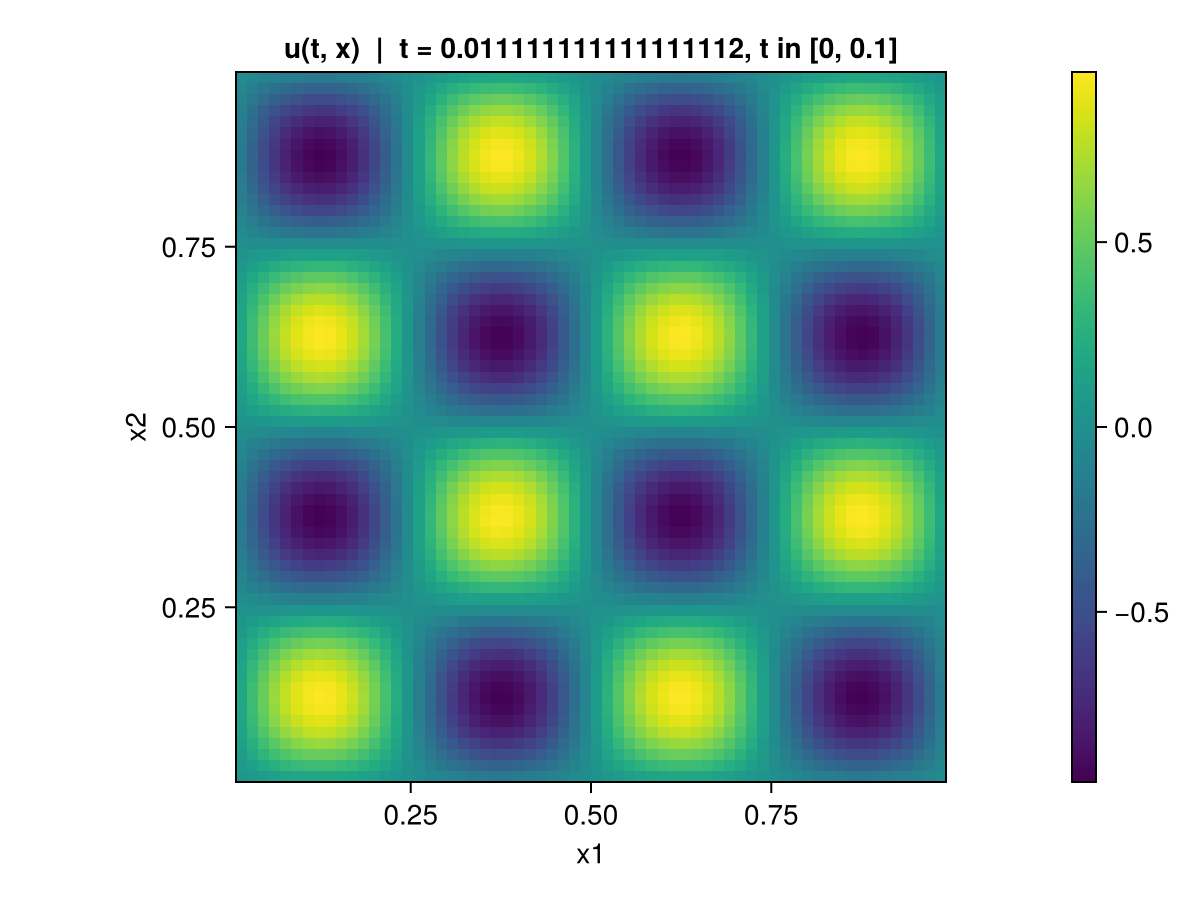

In [95]:
using CairoMakie

ti = 2

t = (ti-1) * tau
U = U_evol_op[ti, :]
#U = u_analytic_fun.(grid_points_as_1d_vect, t);

h = 1/(n+1)
xs = range(h, 1-h; length=n)
U_matrix = reshape(U, ntuple(_ -> n, d)...)

fig, ax, hm = heatmap(xs, xs, U_matrix,
    colormap = :viridis,
    axis = (title = "u(t, x)  |  t = $t, t in [0, $t_max]", xlabel = "x1", ylabel = "x2", aspect = 1)
)
Colorbar(fig[1, 2], hm)
fig